# CLV Modelling

## This document will develop 2 seperate models for Life Time Value predictions. 
1. Probablistic modelling 
2. Machine Learning Modelling

Both models will give predictions on the expected life of a customer and the total monetary value of there expenditure.
The data to be analysed is 2 years worth of  Brazillian E-commerce data. Totalling over 100k of order_c. 

# Method

The process will follow the following steps 
1. Data Collection
    1.1 Environment
2. Data Exploration
    2.2 General metrics 
    2.3 RFM (Recency, Frequency, Monetary Value)
3. Data Cleaning
4. Data Preprocessing 
5. Modelling 
    5.1 Pareto/NBD Model
    5.2 ML modelling
6. Cross Validation
7. Model Selection
8. Web Application

In [1]:
import matplotlib.pyplot as plt

In [2]:
import graphviz

In [3]:
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases


# Environment

In [4]:
import pandas as pd
import pycaret as py
import seaborn as sns
import lifetimes as life
from lifetimes import BetaGeoFitter
from lifetimes import ModifiedBetaGeoFitter


In [5]:

import graphviz
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arviz.labels import MapLabeller

from pymc_marketing import clv
from pymc_marketing.prior import Prior

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


# Loading Data

In [25]:
order_c=pd.read_csv('2009-2010.csv')


FileNotFoundError: [Errno 2] No such file or directory: '2009-2010.csv'

In [22]:
with open("transactions from UK retailer.csv", "r", encoding="utf-8", errors="ignore") as f:
    content = f.read()

In [24]:
content.head()

AttributeError: 'str' object has no attribute 'head'

In [7]:
print(cust_desc.head())
print(cust_desc['customer_id'].nunique())
print(cust_desc['customer_unique_id'].nunique())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
99441
96096


In [8]:
cust_ed=cust_desc[['customer_id','customer_unique_id']]
order_c=order_c.merge(cust_ed,on=['customer_id'],how='left')


In [9]:
order_c.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6


In [10]:
payment_sh=payment[['order_id','payment_value']]
print(payment_sh.dtypes)
payment_sh['order_id']=payment_sh['order_id'].astype(str)


order_id          object
payment_value    float64
dtype: object


# Formating dataframe

In [11]:
order_mapping = {
    'order_id': str,
    'customer_id': str,  
    'order_status': str,
    'order_purchase_timestamp': 'category',
    'customer_unique_id': str
    }

order_c = order_c.astype(order_mapping)

order_c['order_delivered_carrier_date']=pd.to_datetime(order_c['order_delivered_carrier_date'])
order_c['order_delivered_customer_date']=pd.to_datetime(order_c['order_delivered_customer_date'])
order_c['order_estimated_delivery_date']=pd.to_datetime(order_c['order_estimated_delivery_date'])
order_c['order_approved_at']=pd.to_datetime(order_c['order_approved_at'])
order_c['order_purchase_timestamp']=pd.to_datetime(order_c['order_purchase_timestamp'])
order_c['order_purchase_timestamp']= order_c['order_purchase_timestamp'].dt.normalize()


payment_mapping={'order_id':str,
                 'payment_value':'int'}

payment_sh=payment_sh.astype(payment_mapping)

d_orders=order_c.merge(payment_sh,on='order_id',how='left')

order_c.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6


Most expensive item is for 13664 and the average spend is $153

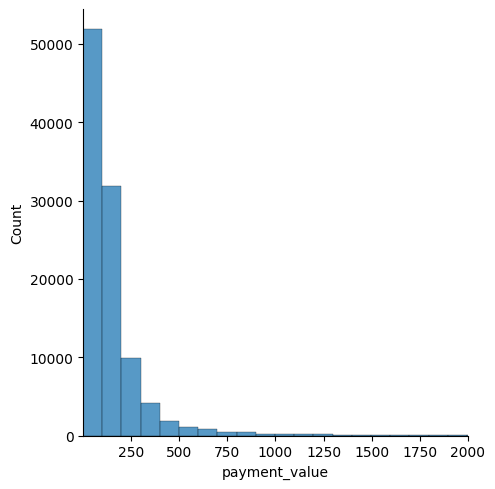

In [12]:
pay_dis=d_orders['payment_value']
sns.displot(pay_dis, binwidth=100)
plt.xlim(1,2000)
plt.show()

In [13]:
print(d_orders['payment_value'].sort_values())
print(d_orders['payment_value'].mean())

352          0.0
84197        0.0
52073        0.0
37302        0.0
40199        0.0
          ...   
29628     6922.0
23138     6929.0
69544     7274.0
13958    13664.0
32133        NaN
Name: payment_value, Length: 103887, dtype: float64
153.62711048649481


In [14]:
d_orders['customer_id'].nunique()

99441

In [15]:
d_orders['customer_id'].count()

103887

# Intial exploration
around 98k of order_c over 2 years, now i want to see it from a customer level. 





In [16]:
print(d_orders['order_status'].value_counts())
print(d_orders['order_estimated_delivery_date'].min())
print(d_orders['order_delivered_customer_date'].max())
print(d_orders['order_id'].sum())

order_status
delivered      100757
shipped          1166
canceled          664
unavailable       649
invoiced          325
processing        319
created             5
approved            2
Name: count, dtype: int64
2016-09-30 00:00:00
2018-10-17 13:22:46
...


# RFM model calls for the following variables
 ### T represents the age of the customer in whatever time units chosen (weekly, in the above dataset). This is equal to the duration between a customer’s first purchase and the end of the period under study.

### Frequency represents the number of repeat purchases the customer has made. This means that it’s one less than the total number of purchases. This is actually slightly wrong. It’s the count of time periods the customer had a purchase in. So if using days as units, then it’s the count of days the customer had a purchase on.

### monetary_value represents the average value of a given customer’s purchases. This is equal to the sum of all a customer’s purchases divided by the total number of purchases. Note that the denominator here is different than the frequency described above.

### recency represents the age of the customer when they made their most recent purchases. This is equal to the duration between a customer’s first purchase and their latest purchase. (Thus if they have made only 1 purchase, the recency is 0.)

## In this part of the model I will
  ### design the correct matrix then run the transaction data through the utility tool of the lifetime tools to get the RFM

In [17]:
rfm_orders= d_orders[['customer_unique_id','order_purchase_timestamp','payment_value']]
rfm_orders.head()

,customer_unique_id,order_purchase_timestamp,payment_value
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,18.0
1,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,2.0
2,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,18.0
3,af07308b275d755c9edb36a90c618231,2018-07-24,141.0
4,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,179.0


In [18]:
rfm_orders.dtypes

customer_unique_id                  object
order_purchase_timestamp    datetime64[ns]
payment_value                      float64
dtype: object

In [19]:
rfm_data = clv.utils.rfm_summary(
    rfm_orders,
    customer_id_col="customer_unique_id",
    datetime_col="order_purchase_timestamp",
    monetary_value_col="payment_value",
    datetime_format="%Y%m%d",
    time_unit="W",
)

rfm_data

,customer_id,frequency,recency,T,monetary_value
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,23.0,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,23.0,0.0
2,0000f46a3911fa3c0805444483337064,0.0,0.0,84.0,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,53.0,0.0
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.0,48.0,0.0
...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,0.0,0.0,71.0,0.0
96092,fffea47cd6d3cc0a88bd621562a9d061,0.0,0.0,45.0,0.0
96093,ffff371b4d645b6ecea244b27531430a,0.0,0.0,88.0,0.0
96094,ffff5962728ec6157033ef9805bacc48,0.0,0.0,24.0,0.0


In [20]:
rfm_data['recency'].value_counts()

recency
0.0     94052
1.0       171
2.0       141
3.0       118
4.0        86
        ...  
70.0        1
90.0        1
82.0        1
77.0        1
87.0        1
Name: count, Length: 81, dtype: int64

<Axes: title={'center': 'Customer Exposure'}, xlabel='Time since first purchase', ylabel='Customer'>

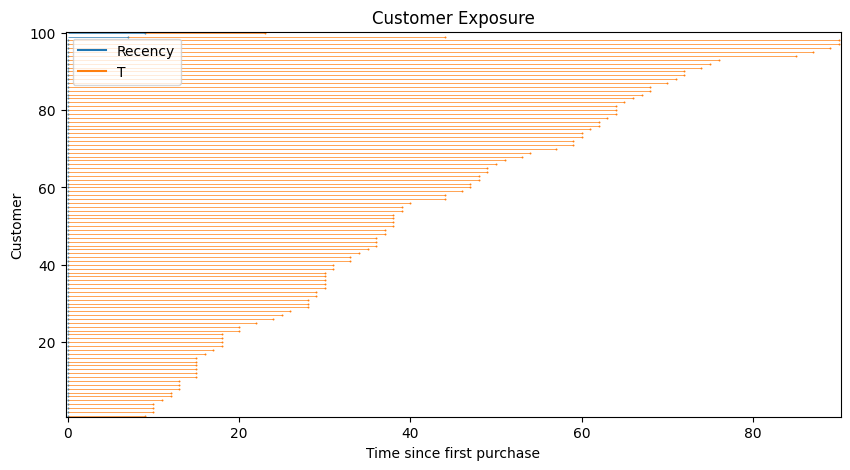

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
(
    rfm_data.sample(n=100, random_state=42)
    .sort_values(["recency", "T"])
    .pipe(clv.plot_customer_exposure, ax=ax, linewidth=0.5, size=0.75))

In [27]:
bgm = clv.BetaGeoModel(data=rfm_data)

bgm.build_model()
bgm.graphviz()

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [23]:
observation_period_ends=pd.to_datetime('2018-10-30')

In [24]:
rfm_orders

,customer_unique_id,order_purchase_timestamp,payment_value
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,18.0
1,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,2.0
2,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,18.0
3,af07308b275d755c9edb36a90c618231,2018-07-24,141.0
4,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,179.0
...,...,...,...
103882,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,85.0
103883,da62f9e57a76d978d02ab5362c509660,2018-02-06,195.0
103884,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,271.0
103885,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,441.0


In [25]:
customer_summary = rfm_orders.groupby('customer_id').agg(
        first_purchase_date=('order_purchase_timestamp', 'min'),
        last_purchase_date=('order_purchase_timestamp', 'max'),
        frequency=('order_purchase_timestamp', lambda x: x.count() - 1),
        monetary_value=('payment_value', 'mean')
    )
customer_summary.head()

KeyError: 'customer_id'

In [ ]:
customer_summary['recency'] = (customer_summary['last_purchase_date'] - customer_summary['first_purchase_date']).dt.days
customer_summary['T'] = (observation_period_ends - customer_summary['first_purchase_date']).dt.days
customer_summary.head()

,first_purchase_date,last_purchase_date,frequency,monetary_value,recency,T
customer_id,,,,,,
00012a2ce6f8dcda20d059ce98491703,2017-11-14,2017-11-14,0,114.0,0,350
000161a058600d5901f007fab4c27140,2017-07-16,2017-07-16,0,67.0,0,471
0001fd6190edaaf884bcaf3d49edf079,2017-02-28,2017-02-28,0,195.0,0,609
0002414f95344307404f0ace7a26f1d5,2017-08-16,2017-08-16,0,179.0,0,440
000379cdec625522490c315e70c7a9fb,2018-04-02,2018-04-02,0,107.0,0,211


In [ ]:
# checking for null
customer_summary.isnull().sum()

first_purchase_date    0
last_purchase_date     0
frequency              0
monetary_value         0
recency                0
T                      0
dtype: int64

In [ ]:
cust_sh=customer_summary[['frequency','monetary_value','recency','T']]
cust_sh.head()

In [ ]:
print(customer_summary[['frequency', 'recency', 'T']].describe())

          frequency  recency             T
count  99437.000000  99437.0  99437.000000
mean       0.043072      0.0    303.275521
std        0.364409      0.0    153.660661
min        0.000000      0.0     13.000000
25%        0.000000      0.0    179.000000
50%        0.000000      0.0    285.000000
75%        0.000000      0.0    413.000000
max       22.000000      0.0    786.000000


In [ ]:
BGF = BetaGeoFitter(penalizer_coef=0.1)
BGF.fit(cust_sh['frequency'], cust_sh['recency'], cust_sh['T'])
print(BGF)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: nan
        x: [-5.393e+04 -4.916e+04 -3.136e+04 -3.826e+04]
      nit: 13
      jac: [       nan        nan        nan        nan]
 hess_inv: [[ 1.638e+04  1.491e+04  9.521e+03  1.161e+04]
            [ 1.491e+04  1.357e+04  8.666e+03  1.057e+04]
            [ 9.521e+03  8.666e+03  5.535e+03  6.751e+03]
            [ 1.161e+04  1.057e+04  6.751e+03  8.236e+03]]
     nfev: 125
     njev: 125


ConvergenceError: 
The model did not converge. Try adding a larger penalizer to see if that helps convergence.


In [ ]:

summary_cal_holdout = calibration_and_holdout_data(d_orders, 'customer_id', 'order_purchase_timestamp',
                                        calibration_period_end='2016-10-01',
                                        observation_period_end='2018-10-01' )
print(summary_cal_holdout.head())

KeyboardInterrupt: 

In [ ]:
summary_cal_holdout['frequency_cal'].value_counts()

frequency_cal
0.0    4
Name: count, dtype: int64

In [ ]:
bgf = BetaGeoFitter(penalizer_coef=0.0)

In [ ]:

bgf.fit(summary_cal_holdout['frequency_cal'], summary_cal_holdout['recency_cal'], summary_cal_holdout['T_cal'])
plot_calibration_purchases_vs_holdout_purchases(bgf, summary_cal_holdout)

LinAlgError: Singular matrix

In [ ]:
ggf = GammaGammaFitter(penalizer_coef = 0)
ggf.fit(returning_customers_summary['frequency'],
        returning_customers_summary['monetary_value'])
print(ggf)
"""

SyntaxError: incomplete input (3242569376.py, line 5)

In [ ]:
summary_with_money_value = load_cdnow_summary_data_with_monetary_value()
summary_with_money_value.head()
returning_customers_summary = summary_with_money_value[summary_with_money_value['frequency']>0]

print(returning_customers_summary.head())

NameError: name 'load_cdnow_summary_data_with_monetary_value' is not defined